In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import numpy as np

In [2]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/MODSNOW_irrigated_MarJul_2000_2024/MOD13Q1.061_250m_aid0001.nc'

ds = xr.open_dataset(ndvi_path)

ndvi = ds['_250m_16_days_NDVI']

In [3]:
ndvi

<xarray.DataArray '_250m_16_days_NDVI' (time: 588, lat: 1081, lon: 1601)> Size: 8GB
[1017640428 values with dtype=float64]
Coordinates:
  * time     (time) object 5kB 2000-02-18 00:00:00 ... 2025-08-29 00:00:00
  * lat      (lat) float64 9kB 43.33 43.33 43.33 43.33 ... 41.09 41.09 41.08
  * lon      (lon) float64 13kB 58.17 58.17 58.17 58.17 ... 61.49 61.5 61.5 61.5
Attributes: (12/13)
    grid_mapping:      crs
    valid_min:         -2000
    valid_max:         10000
    add_offset_err:    0.0
    calibrated_nt:     5
    long_name:         250m 16 days NDVI
    ...                ...
    units:             NDVI
    AREA_OR_POINT:     Area
    transform:         [ 2.31656358e+02  0.00000000e+00  4.66787562e+06  0.00...
    res:               [231.65635826 231.65635826]
    is_tiled:          1
    nodatavals:        -3000.0

In [4]:
ndvi_JA = ndvi.where(ndvi['time.month'].isin([7, 8]), drop=True)
ndvi_JA_mean = ndvi_JA.mean(dim='time', skipna=True)
veg_mask = ndvi_JA_mean > 0.2

In [5]:
ndvi_veg = ndvi.where(veg_mask)

In [6]:
ndvi_veg.min().values, ndvi_veg.max().values

(array(-0.2), array(0.9982))

In [7]:
ndvi_veg.name = 'NDVI_vegetated'

ndvi_veg.attrs = {
    'description': (
        'MOD13Q1 NDVI time series for vegetated pixels only. '
        'Vegetation defined as mean July–August NDVI > 0.2.'
    ),
    'vegetation_threshold': 0.2
}

ndvi_veg.to_netcdf(
    'NDVI_vegetated_MOD13Q1.nc',
    encoding={'NDVI_vegetated': {'zlib': True, 'complevel': 4}}
)


In [9]:
ndvi_veg.dims

('time', 'lat', 'lon')

In [8]:
veg_mask.name = 'vegetation_mask'
veg_mask.astype('int8').to_netcdf('vegetation_mask.nc')


In [ ]:
ndvi_pixel_mean = ndvi_veg.mean(dim='time', skipna=True)

/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


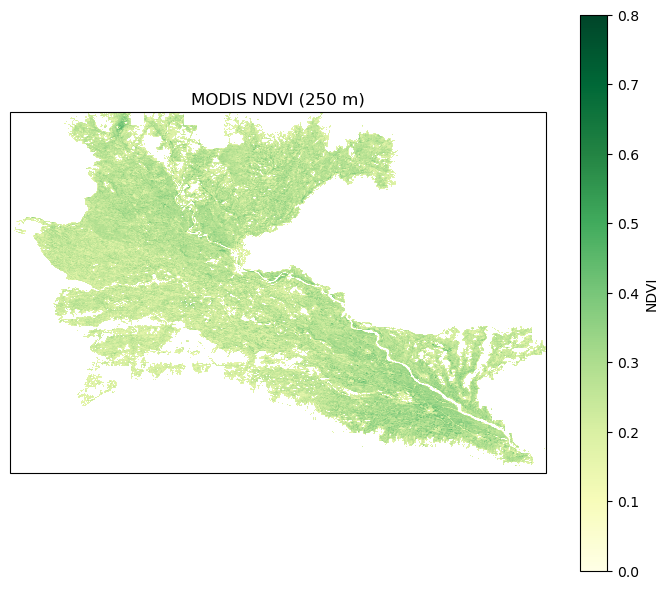

In [10]:
ndvi_map = ndvi_pixel_mean


fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ndvi_map.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    vmin=0,
    vmax=0.8,
    cbar_kwargs={'label': 'NDVI'}
)

ax.coastlines()
ax.set_title('MODIS NDVI (250 m)')
plt.tight_layout()
plt.show()

# Subset

In [ ]:
ndvi_valid = ndvi.where(ndvi != -3000)

# Now this actually means "has real data"
valid_mask = ndvi_valid.notnull().any(dim='time')

iy, ix = np.where(valid_mask.values)

print("Number of valid pixels:", len(iy))

# Take the first valid one
iy0, ix0 = iy[0], ix[0]

In [ ]:
ndvi_sub = ndvi.isel(
    lat=slice(max(0, iy0 - 10), iy0 + 10),
    lon=slice(max(0, ix0 - 10), ix0 + 10)
)

In [ ]:
ndvi_test = ndvi_sub.sel(time='2000-02-18').where(ndvi_sub != -3000) 

print("Min:", ndvi_test.min().item())
print("Max:", ndvi_test.max().item())

In [ ]:
ndvi_sub.name = 'NDVI_sub'

ndvi_sub.attrs = {
    'description': (
        'Subset of MOD13Q1 NDVI time series for vegetated pixels only. '
        'Vegetation defined as mean July–August NDVI > 0.2.'
    ),
    'vegetation_threshold': 0.2
}

ndvi_sub.to_netcdf(
    '/Users/tillweiss/Desktop/MODSNOW/data/NDVI_sub.nc',
    encoding={'NDVI_sub': {'zlib': True, 'complevel': 4}}
)


In [9]:
snow_path = '/Users/tillweiss/Desktop/MODSNOW/data/cloud_snow_fraction_amudarya_kerky_4report.txt'

snow = pd.read_csv(snow_path,
    sep=';',
    header=None,
    engine='python'
)

snow.columns = ['Year', 'Day', 'Snow_Mean', 'Snow_Percent','nn']
snow['Snow_Mean'] = snow['Snow_Mean'].replace(-9, pd.NA)

snow['Date'] = pd.to_datetime(
    snow['Year'].astype(int).astype(str),
    format='%Y'
) + pd.to_timedelta(snow['Day'] - 1, unit='D')

snow_df = snow[['Date', 'Snow_Percent']]
snow_df

,Date,Snow_Percent
0,2000-02-26,54.58
1,2000-02-27,55.93
2,2000-02-28,56.73
3,2000-02-29,56.78
4,2000-03-01,56.29
...,...,...
9245,2025-06-20,6.18
9246,2025-06-21,8.12
9247,2025-06-22,5.59
9248,2025-06-23,6.48


In [17]:
snow_df['Date'] = pd.to_datetime(snow_df['Date'])

# Align snow data with NDVI time
ndvi['time'] = pd.to_datetime(ndvi['time'].values)
snow_series = snow_df.set_index('Date')['Snow_Percent'].reindex(ndvi['time'].values)

# Keep only valid times
valid_idx = ~snow_series.isna()
ndvi_filtered = ndvi.isel(time=np.where(valid_idx)[0])
snow_series_filtered = snow_series[valid_idx].values

/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_12309/1530151417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snow_df['Date'] = pd.to_datetime(snow_df['Date'])


TypeError: <class 'cftime._cftime.DatetimeJulian'> is not convertible to datetime, at position 0

In [ ]:
# NDVI shape: (time, lat, lon)
ndvi_vals = ndvi_filtered.values  # shape (t, lat, lon)
t, lat, lon = ndvi_vals.shape

# Reshape to 2D: (time, pixels)
ndvi_2d = ndvi_vals.reshape(t, lat*lon)

# Standardise
ndvi_std = (ndvi_2d - np.nanmean(ndvi_2d, axis=0)) / np.nanstd(ndvi_2d, axis=0)
snow_std = (snow_series_filtered - np.nanmean(snow_series_filtered)) / np.nanstd(snow_series_filtered)

# Correlation along time
corr_flat = np.nanmean(ndvi_std * snow_std[:, None], axis=0)

# Reshape back to (lat, lon)
corr_map = corr_flat.reshape(lat, lon)


In [20]:
import cftime
import pandas as pd

# If your netCDF time uses cftime.DatetimeJulian
def cftime_to_datetime(cftime_array):
    return pd.to_datetime([pd.Timestamp(t.year, t.month, t.day) for t in cftime_array])

ndvi['time'] = cftime_to_datetime(ndvi['time'].values)

In [ ]:
ndvi['time'] = pd.to_datetime(ndvi['time'].values)

# --- 2. Load Snow_Percent DataFrame ---  # replace with your file
snow_df['Date'] = pd.to_datetime(snow_df['Date'])

# Align snow data with NDVI times
snow_series = snow_df.set_index('Date')['Snow_Percent'].reindex(ndvi['time'].values)
valid_idx = ~snow_series.isna()
ndvi_filtered = ndvi.isel(time=np.where(valid_idx)[0])
snow_series_filtered = snow_series[valid_idx].values


# --- 3. Prepare NDVI array ---
ndvi_vals = ndvi_filtered.values  # shape (time, lat, lon)
t, lat, lon = ndvi_vals.shape

# Reshape NDVI to 2D: (time, pixels)
ndvi_2d = ndvi_vals.reshape(t, lat*lon)

# --- 4. Standardise (handle NaNs) ---
ndvi_mean = np.nanmean(ndvi_2d, axis=0)
ndvi_std = np.nanstd(ndvi_2d, axis=0)
ndvi_std[ndvi_std == 0] = np.nan  # avoid divide by zero
ndvi_norm = (ndvi_2d - ndvi_mean) / ndvi_std

snow_norm = (snow_series_filtered - np.nanmean(snow_series_filtered)) / np.nanstd(snow_series_filtered)

# --- 5. Pixel-wise correlation ---
# multiply and average along time
corr_flat = np.nanmean(ndvi_norm * snow_norm[:, None], axis=0)

# Reshape back to (lat, lon)
corr_map = corr_flat.reshape(lat, lon)

# --- 6. Wrap as xarray DataArray ---
corr_da = xr.DataArray(
    corr_map,
    coords={'lat': ndvi_filtered.lat, 'lon': ndvi_filtered.lon},
    dims=['lat', 'lon'],
    name='ndvi_snow_corr'
)

# --- 7. Save result ---
corr_da.to_netcdf("ndvi_snow_correlation.nc")

print("Pixel-wise correlation calculation completed.")

/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_12309/3238393477.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snow_df['Date'] = pd.to_datetime(snow_df['Date'])
/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_12309/3238393477.py:21: RuntimeWarning: Mean of empty slice
  ndvi_mean = np.nanmean(ndvi_2d, axis=0)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
